## Essay Evaluation Parallel Workflow

In [54]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
import operator
load_dotenv()
model = ChatOpenAI(model='gpt-4o-mini')

### Define Output Structured Schema

In [55]:
class GetStructuredOutput(BaseModel):
    feedback : str = Field(description='Detailed feedback for the essay')
    score : int = Field(description='Score out of 10', ge=0, le=10)

structured_model = model.with_structured_output(GetStructuredOutput)

### Essay written by user on the topic

In [56]:
essay = """
**Evaluation of Artificial Intelligence in India**

Artificial Intelligence (AI) has emerged as a transformative force globally, and India is no exception. Over the past decade, the country has witnessed rapid growth in AI adoption across sectors such as healthcare, agriculture, education, finance, and governance. Evaluating AI in India requires an analysis of its opportunities, challenges, and overall impact on society and the economy.

One of the most significant advantages of AI in India is its potential to drive economic growth. With a large pool of skilled IT professionals and a thriving startup ecosystem, India is well-positioned to become a global hub for AI innovation. Government initiatives such as the National AI Strategy and programs promoting digital infrastructure have further accelerated AI development. AI-powered automation and data analytics are enhancing productivity in industries, improving decision-making, and creating new business opportunities.

In sectors like healthcare, AI is playing a crucial role in improving diagnostics, predicting diseases, and optimizing treatment plans. For a country with a vast population and limited healthcare resources, AI can bridge gaps by enabling remote consultations and early detection of illnesses. Similarly, in agriculture, AI tools help farmers monitor crop health, predict weather patterns, and increase yield, which is vital for a largely agrarian economy.

Education is another domain where AI is making a meaningful impact. Personalized learning platforms powered by AI are helping students learn at their own pace, addressing the diverse educational needs of India's population. In governance, AI is being used to enhance public service delivery, reduce corruption, and improve administrative efficiency through data-driven insights.

However, despite these advantages, AI adoption in India faces several challenges. One of the primary concerns is the lack of adequate infrastructure and access to high-quality data. Rural areas, in particular, lag behind in digital connectivity, which limits the reach of AI solutions. Additionally, there is a shortage of advanced AI research capabilities compared to leading countries, which can hinder innovation.

Ethical and social issues also arise with the increasing use of AI. Concerns about data privacy, algorithmic bias, and job displacement are significant. Automation may replace certain low-skilled jobs, creating economic inequality if reskilling initiatives are not implemented effectively. Furthermore, the absence of comprehensive regulatory frameworks for AI raises questions about accountability and transparency.

Another critical aspect is inclusivity. For AI to truly benefit India, it must be designed to cater to its diverse population, including different languages, cultures, and socio-economic backgrounds. Without inclusive development, AI risks widening the digital divide rather than reducing it.

In conclusion, AI holds immense promise for India’s development, offering solutions to some of the country’s most pressing challenges. While progress has been encouraging, a balanced approach is necessary to address the associated risks. Strengthening infrastructure, investing in education and research, ensuring ethical practices, and promoting inclusive growth will be key to maximizing the benefits of AI in India. With the right strategies, AI can become a powerful tool for sustainable and equitable development in the country.
"""

### Prepare a prompt to send an LLM to evaluate the Essay written by user.

In [57]:
prompt = f'Evaluate a quality of the following essay and provide the feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt)

GetStructuredOutput(feedback='The essay provides a clear and comprehensive evaluation of the role of Artificial Intelligence (AI) in India, highlighting both the opportunities and challenges faced by the country. The structure is logical, with an introduction, body paragraphs focusing on specific sectors, challenges, and concluding remarks. The language is articulate and appropriately formal for the subject matter. However, the essay could benefit from some statistical data or specific examples to strengthen the arguments presented, particularly in discussing economic impacts and technology adoption rates. Additional citations or references to studies would also enhance credibility. Lastly, while the conclusion effectively summarizes key points, it could be more impactful by including a strong call to action or a vision for the future.', score=8)

### Define a State

In [58]:
class UPSCstate(TypedDict):
    essay : str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    individual_scores : Annotated[list[int], operator.add]
    overall_feedback : float
    avg_score : float
    

### Define Graph

In [59]:
graph = StateGraph(UPSCstate)

### Add Nodes

In [ ]:
def Evaluate_Language(state: UPSCstate):
    prompt = f'Evaluate the language quality of the following essay and provide feedback assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)
    return {'language_feedback':output.feedback,
            'individual_scores': [output.score]}

def Evaluate_Analysis(state: UPSCstate):
    prompt = f'Evaluate the depth of analysis of the following essay and provide feedback assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)
    return {'analysis_feedback':output.feedback,
            'individual_scores': [output.score]}

def Evaluate_Thought(state: UPSCstate):
    prompt = f'Evaluate the clarity of the thought of the following essay and provide feedback assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)
    return {'clarity_feedback':output.feedback,
            'individual_scores': [output.score]}

def Final_Evaluation(state: UPSCstate):
    prompt = f'Based on the following feedbacks create a summurized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    avg_scores = sum(state['individual_scores']) / len(state['individual_scores'])

    return {'overall_feedback':overall_feedback,
            'avg_score': avg_scores}

graph.add_node('Evaluate_Language', Evaluate_Language)
graph.add_node('Evaluate_Analysis', Evaluate_Analysis)
graph.add_node('Evaluate_Thought', Evaluate_Thought)
graph.add_node('Final_Evaluation', Final_Evaluation)

### Define edges

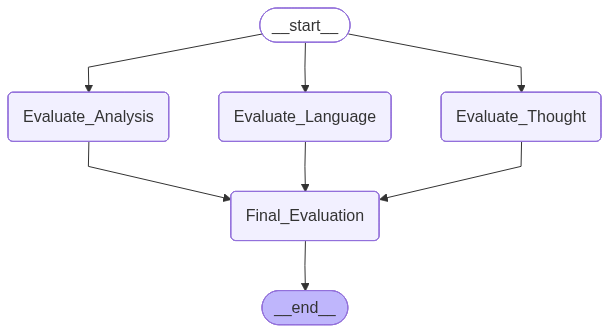

In [61]:
graph.add_edge(START, 'Evaluate_Language')
graph.add_edge(START, 'Evaluate_Analysis')
graph.add_edge(START, 'Evaluate_Thought')

graph.add_edge('Evaluate_Language', 'Final_Evaluation')
graph.add_edge('Evaluate_Analysis', 'Final_Evaluation')
graph.add_edge('Evaluate_Thought', 'Final_Evaluation')

graph.add_edge('Final_Evaluation', END)

workflow = graph.compile()
graph.compile()

### Execute Graph

In [62]:
initial_state = {'essay' : essay}

final_state = workflow.invoke(initial_state)
print(final_state)

TypeError: can only concatenate list (not "int") to list